## 1. Imports

In [9]:
# import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import (RandomForestRegressor,ExtraTreesRegressor, BaggingRegressor)
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import time
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

import joblib
import os

import warnings
warnings.filterwarnings('ignore')

## 2. Load Data

In [10]:
# Notebook 2 (Training): Load
df_final = pd.read_parquet('../data/tehranhouses_preprocessed.parquet')
df_final.head()

,Area,Room,Parking,Warehouse,Elevator,Price(USD),Address_Abbasabad,Address_Absard,Address_Abuzar,Address_Afsarieh,...,Address_Waterfall,Address_West Ferdows Boulevard,Address_West Pars,Address_Yaftabad,Address_Yakhchiabad,Address_Yousef Abad,Address_Zafar,Address_Zaferanieh,Address_Zargandeh,Address_Zibadasht
0,63,1,1,1,1,61666.67,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,60,1,1,1,1,61666.67,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,79,2,1,1,1,18333.33,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,95,2,1,1,1,30083.33,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,123,2,1,1,1,233333.33,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [11]:
# Feature / Target Split
X = df_final.drop('Price(USD)', axis=1)
y = df_final['Price(USD)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (2760, 196)  |  Test: (690, 196)


In [19]:
from pycaret.regression import setup, compare_models, create_model, tune_model, finalize_model, evaluate_model, save_model

# Initialize PyCaret Setup
exp_reg = setup(
    data=df_final,
    target='Price(USD)',
    session_id=42,
    train_size=0.8,
    normalize=True,
    normalize_method='zscore',
    n_jobs=1
)

best_model = compare_models(
    include=[
        'lightgbm',  # LightGBM
        'catboost',  # CatBoost
        'xgboost',   # XGBoost
        'rf',        # Random Forest
        'et',        # Extra Trees
        'gbr',       # Gradient Boosting
        'ridge',     # Ridge Regression
        'knn'        # K-Nearest Neighbors
    ],
    fold=5,
    sort='R2'
)

,Description,Value
0,Session id,42
1,Target,Price(USD)
2,Target type,Regression
3,Original data shape,"(3450, 197)"
4,Transformed data shape,"(3450, 197)"
5,Transformed train set shape,"(2760, 197)"
6,Transformed test set shape,"(690, 197)"
7,Numeric features,5
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,46716.0972,17802985557.1238,131540.9470,0.7478,0.4502,0.4037,1.3820
catboost,CatBoost Regressor,48406.7706,18592948502.8418,134054.8882,0.7368,0.4889,0.4327,0.6720
xgboost,Extreme Gradient Boosting,47767.4383,19979303116.8000,138629.6391,0.7198,0.4475,0.3937,0.1640
lightgbm,Light Gradient Boosting Machine,56820.3762,19874181380.0055,139862.8333,0.7166,0.5561,0.5289,0.1180
rf,Random Forest Regressor,50515.4369,20272631556.4571,141156.9627,0.7122,0.4619,0.4243,0.9240
gbr,Gradient Boosting Regressor,60573.1612,23368965587.3963,150690.5832,0.6696,0.5841,0.6510,0.3360
knn,K Neighbors Regressor,55457.3664,25713674240.0000,160016.1375,0.6415,0.4863,0.4481,0.0540
ridge,Ridge Regression,70500.7089,25957071121.7767,159946.6048,0.6316,0.8536,0.9353,0.1000


## . Model Building & Evaluation

### 7.2 Train with GridSearchCV (5-Fold CV)

### 7.3 Model Comparison Table

### 7.4 Visual Comparison

### 7.5 CV R² vs Test R² (Overfitting Check)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

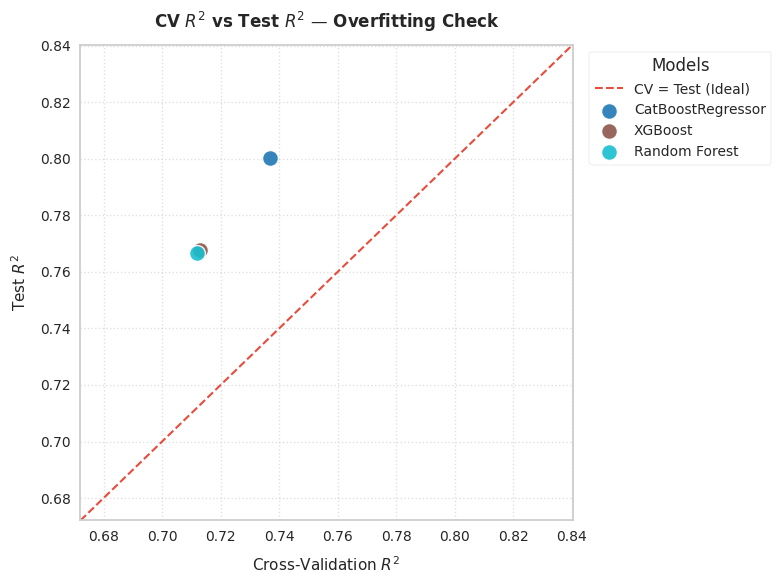

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))

# Ensure data types are correct
cv_r2   = metrics_df['CV R²'].astype(float)
test_r2 = metrics_df['Test R²'].astype(float)

# Dynamic axis limits
min_val = max(0, min(cv_r2.min(), test_r2.min())) - 0.04
max_val = min(1.0, max(cv_r2.max(), test_r2.max())) + 0.04
lim = [min_val, max_val]

# Plot the ideal line in the background
ax.plot(lim, lim, color='#e74c3c', linestyle='--', linewidth=1.5, label='CV = Test (Ideal)', zorder=1)

# Plot each model individually to generate distinct colors for the legend box
colors = plt.cm.get_cmap('tab10', len(metrics_df))

for i, (name, cv, test) in enumerate(zip(metrics_df.index, cv_r2, test_r2)):
    ax.scatter(cv, test, color=colors(i), s=130, alpha=0.9, edgecolors='w', linewidth=1, label=name, zorder=3)

# Formatting and Layout
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel('Cross-Validation $R^2$', fontsize=11, labelpad=8)
ax.set_ylabel('Test $R^2$', fontsize=11, labelpad=8)
ax.set_title('CV $R^2$ vs Test $R^2$ — Overfitting Check', fontsize=12, pad=12, fontweight='bold')

# Place the box in the upper-left (or lower-right) corner
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, shadow=False, title="Models")
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### 7.6 Model

In [18]:
# Define the parameter grid for tuning
param_grid = {
    'iterations': [1000],
    'learning_rate': [0.05],
    'depth': [8, 10, 12],
    # 'l2_leaf_reg': [5, 7],
}

# Set up the GridSearchCV with CatBoostRegressor
grid_search = GridSearchCV(
    estimator=CatBoostRegressor(random_state=42, verbose=0),
    param_grid=param_grid,
    cv=5,              # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1          # Use all available CPU cores
)

# Run the grid search
grid_search.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:
# Print out the best parameters and cross-validation score
print("Best hyperparameters found:")
print(grid_search.best_params_)
print("\nBest cross-validation accuracy: {:.2f}%".format(grid_search.best_score_ * 100))

best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print("Test set accuracy: {:.2f}%".format(test_accuracy * 100))

Best hyperparameters found:
{'depth': 12, 'iterations': 1000, 'learning_rate': 0.05}

Best cross-validation accuracy: 75.28%
Test set accuracy: 80.66%


In [ ]:
# Predict & Evaluate
predictions = best_model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"Model Performance: \n")
print(f"Mean Squared Error: {mse:.4f}")
print("RMSE: %f" % (rmse))
print(f"R^2 Score: {r2:.4f}")

Model Performance: 

Mean Squared Error: 14616606852.0127
RMSE: 120899.159848
R^2 Score: 0.8066


### 7.7 Actual vs Predicted

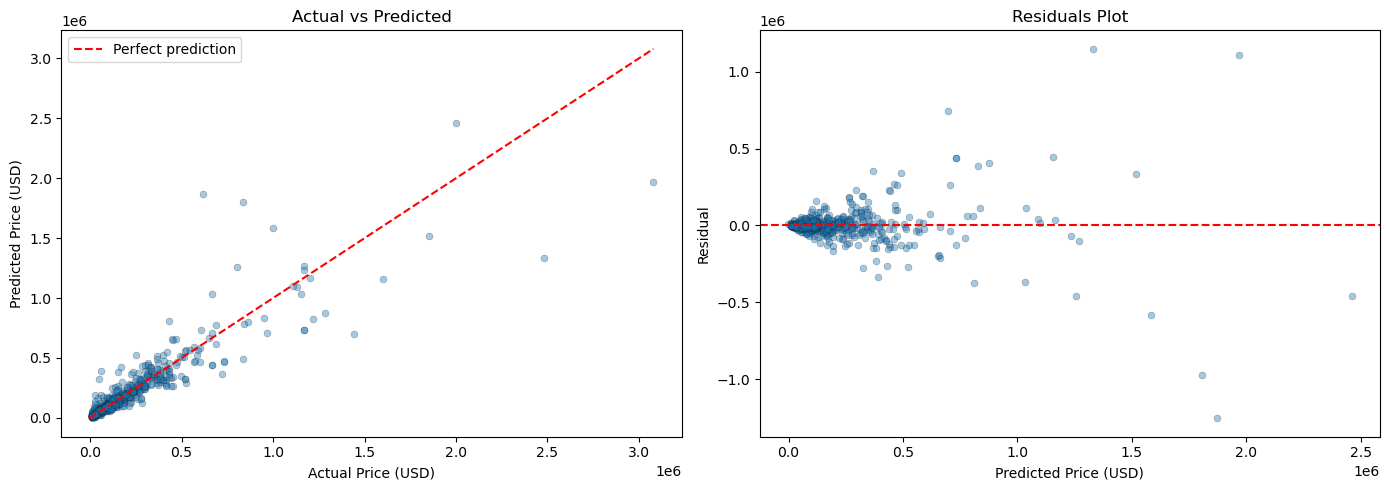

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
y_pred_best = best_model.predict(X_test)

# Scatter: Actual vs Predicted
ax = axes[0]
ax.scatter(y_test, y_pred_best, alpha=0.4, edgecolors='k', linewidths=0.3, s=25)
lim = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
ax.plot(lim, lim, 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Price (USD)'); ax.set_ylabel('Predicted Price (USD)')
ax.set_title(f'Actual vs Predicted'); ax.legend()

# Residuals
ax = axes[1]
residuals = y_test.values - y_pred_best
ax.scatter(y_pred_best, residuals, alpha=0.4, edgecolors='k', linewidths=0.3, s=25)
ax.axhline(0, color='r', linestyle='--', lw=1.5)
ax.set_xlabel('Predicted Price (USD)'); ax.set_ylabel('Residual')
ax.set_title('Residuals Plot')

plt.tight_layout(); plt.show()

### 7.8 Feature Importances

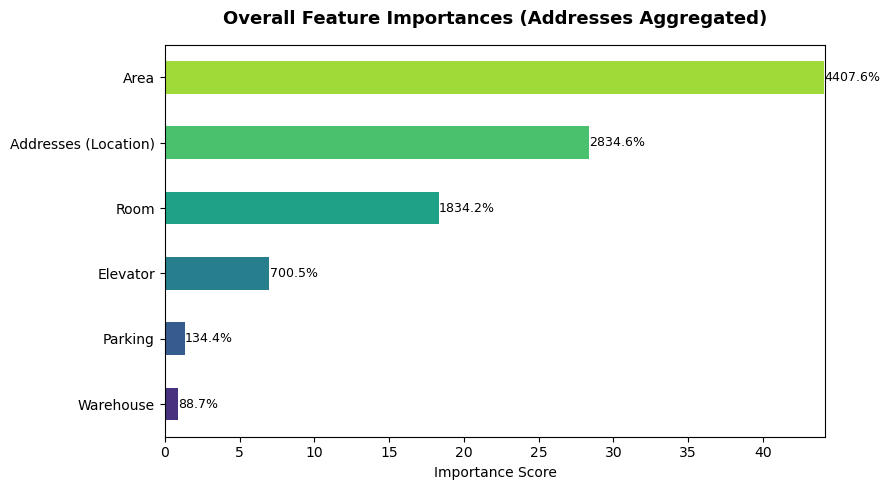

In [ ]:
# Feature Importances
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=X_train.columns)
    
    # Extract and sum up all one-hot encoded 'Address_' column scores
    address_mask = imp.index.str.startswith('Address_')
    total_address_importance = imp[address_mask].sum()
    
    # Build a new series grouping all other numerical features + the unified Address score
    grouped_imp = imp[~address_mask].copy()
    grouped_imp['Addresses (Location)'] = total_address_importance
    
    # Sort them for the plot
    grouped_imp = grouped_imp.sort_values(ascending=True)

    # Plot the unified feature importances
    plt.figure(figsize=(9, 5))
    grouped_imp.plot.barh(color=sns.color_palette('viridis', len(grouped_imp)))
    
    # Add data labels inside/next to the bars
    for i, val in enumerate(grouped_imp.values):
        plt.text(val + 0.005, i, f"{val*100:.1f}%", va='center', fontsize=9, fontweight='medium')
        
    plt.title('Overall Feature Importances (Addresses Aggregated)', fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('Importance Score')
    plt.xlim(0, max(grouped_imp.values) + 0.08)  # Leave room for text labels
    plt.tight_layout()
    plt.show()
else:
    print("The best model does not expose feature_importances_.")

## 8. Save Trained Model

In [ ]:
# Save Trained Model
os.makedirs('saved_models', exist_ok=True)

model_filename = 'saved_models/tehran_housing_best_model.pkl'
features_filename = 'saved_models/model_features.pkl'

# Save the best model and the specific column layout
joblib.dump(best_model, model_filename)
joblib.dump(X_train.columns.tolist(), features_filename)

['saved_models/model_features.pkl']